# Email Spam Detector — Data Exploration

## Project Objective

The goal of this project is to build a machine learning system that classifies messages as either spam or legitimate (ham).

This notebook focuses on understanding and preparing the dataset before model development.

## Workflow

1. Load the dataset
2. Inspect the data
3. Understand the target labels
4. Check for missing values and duplicates
5. Explore the class distribution
6. Analyze message characteristics
7. Prepare the data for machine learning

In [1]:
import pandas as pd

In [2]:
file_path = "../data/SMSSpamCollection"

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5572, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [5]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [6]:
label_counts = df["label"].value_counts()

label_percentages = df["label"].value_counts(normalize=True) * 100

label_percentages

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

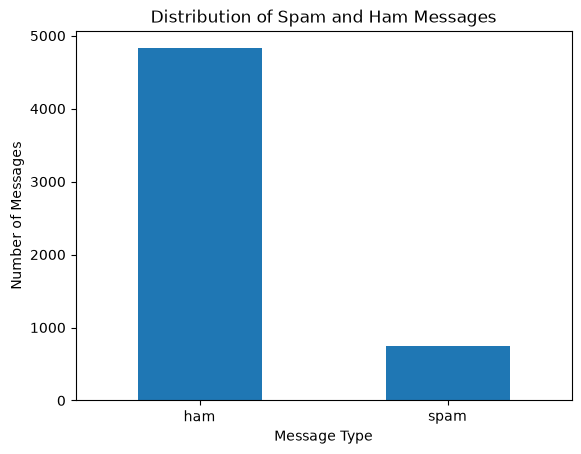

In [7]:
import matplotlib.pyplot as plt

label_counts = df["label"].value_counts()

label_counts.plot(kind="bar")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)

plt.show()

In [8]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(403)

In [10]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(10)

,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
12,spam,URGENT! You have won a 1 week FREE membership ...
45,ham,No calls..messages..missed calls
62,ham,Its a part of checking IQ
65,spam,"As a valued customer, I am pleased to advise y..."
66,ham,"Today is ""song dedicated day.."" Which song wil..."


In [11]:
duplicate_label_counts = (
    duplicates.groupby("message")["label"]
    .nunique()
)

duplicate_label_counts.value_counts()

label
1    281
Name: count, dtype: int64

In [12]:
df_clean = df.drop_duplicates().copy()

In [13]:
df_clean.shape

(5169, 2)

In [14]:
df_clean.duplicated().sum()

np.int64(0)

In [15]:
df_clean["message_length"] = df_clean["message"].str.len()

In [16]:
df_clean[["label", "message", "message_length"]].head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [17]:
df_clean["message_length"].describe()

count    5169.000000
mean       79.344554
std        58.437457
min         2.000000
25%        36.000000
50%        61.000000
75%       119.000000
max       910.000000
Name: message_length, dtype: float64

In [18]:
df_clean.groupby("label")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


In [19]:
import matplotlib.pyplot as plt

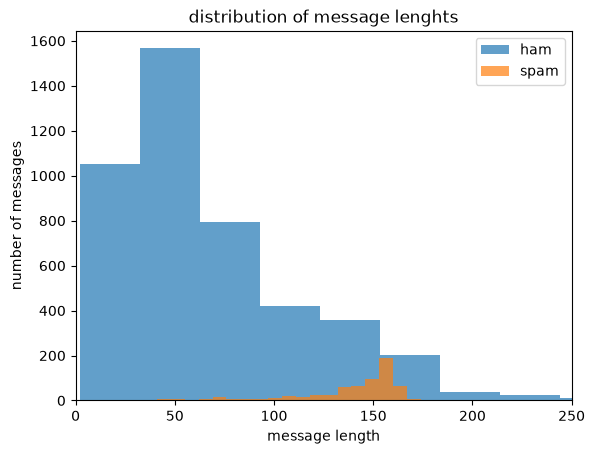

In [20]:
plt.hist(
    df_clean[df_clean["label"] == "ham"]["message_length"],
    bins=30,
    alpha=0.7,
    label="ham"
)
plt.hist(
    df_clean[df_clean["label"] == "spam"]["message_length"],
    bins=30,
    alpha=0.7,
    label="spam"
)

plt.xlim(0, 250)

plt.xlabel("message length")
plt.ylabel("number of messages")
plt.title("distribution of message lenghts")
plt.legend()
plt.show()

In [21]:
df_clean[df_clean["label"] == "spam"]["message"].head(10)

2     Free entry in 2 a wkly comp to win FA Cup fina...
5     FreeMsg Hey there darling it's been 3 week's n...
8     WINNER!! As a valued network customer you have...
9     Had your mobile 11 months or more? U R entitle...
11    SIX chances to win CASH! From 100 to 20,000 po...
12    URGENT! You have won a 1 week FREE membership ...
15    XXXMobileMovieClub: To use your credit, click ...
19    England v Macedonia - dont miss the goals/team...
34    Thanks for your subscription to Ringtone UK yo...
42    07732584351 - Rodger Burns - MSG = We tried to...
Name: message, dtype: str

In [22]:
from collections import Counter

spam_messages = df_clean[df_clean["label"] == "spam"]["message"]

spam_words = " ".join(spam_messages).lower().split()

spam_word_counts = Counter(spam_words)

spam_word_counts.most_common(20)

[('to', 594),
 ('a', 330),
 ('call', 298),
 ('your', 241),
 ('you', 226),
 ('for', 183),
 ('the', 181),
 ('free', 157),
 ('or', 157),
 ('2', 151),
 ('is', 138),
 ('on', 119),
 ('ur', 119),
 ('from', 118),
 ('have', 115),
 ('txt', 114),
 ('and', 104),
 ('text', 96),
 ('u', 96),
 ('mobile', 95)]

In [23]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

spam_words_no_stopwords = [
    word for word in spam_words
    if word not in ENGLISH_STOP_WORDS
]

spam_word_counts_no_stopwords = Counter(spam_words_no_stopwords)

spam_word_counts_no_stopwords.most_common(20)

[('free', 157),
 ('2', 151),
 ('ur', 119),
 ('txt', 114),
 ('text', 96),
 ('u', 96),
 ('mobile', 95),
 ('reply', 93),
 ('claim', 89),
 ('&', 89),
 ('stop', 84),
 ('4', 75),
 ('just', 67),
 ('new', 64),
 ('send', 56),
 ('now!', 54),
 ('prize', 53),
 ('won', 53),
 ('nokia', 53),
 ('contact', 51)]

In [24]:
ham_messages = df_clean[df_clean["label"] == "ham"]["message"]

ham_words = " ".join(ham_messages).lower().split()

ham_words_no_stopwords = [
    word for word in ham_words
    if word not in ENGLISH_STOP_WORDS
]

ham_word_counts = Counter(ham_words_no_stopwords)

ham_word_counts.most_common(20)

[('u', 801),
 ("i'm", 358),
 ('2', 276),
 ('just', 274),
 ('&lt;#&gt;', 254),
 ('got', 222),
 ('like', 214),
 ('come', 202),
 ('ur', 200),
 ('know', 197),
 ('?', 178),
 ('good', 173),
 ('.', 160),
 ('...', 159),
 ('ü', 157),
 ('4', 157),
 ('going', 152),
 ('want', 150),
 ('ok', 146),
 ('time', 145)]

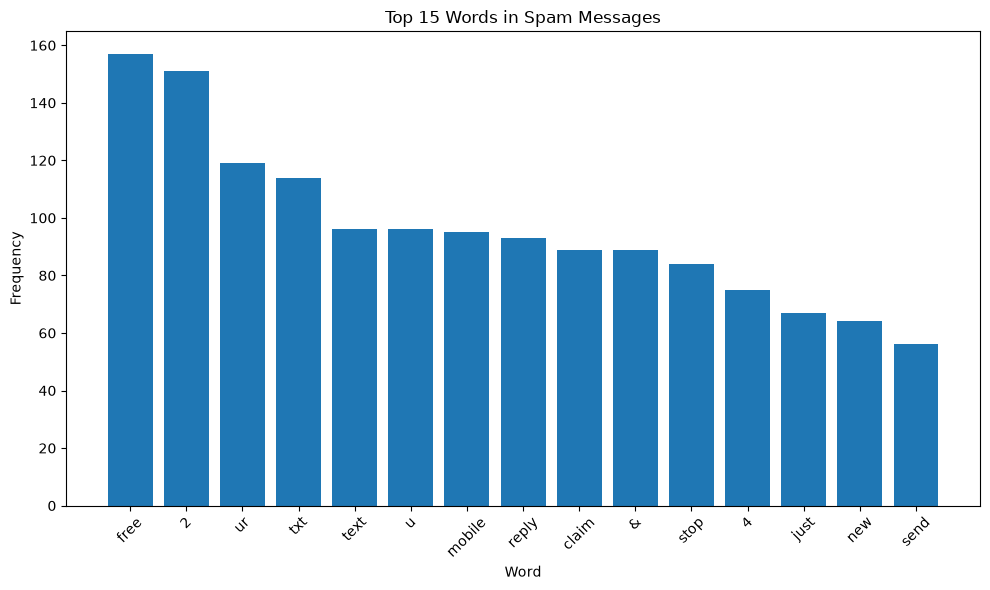

In [25]:
top_spam_words = spam_word_counts_no_stopwords.most_common(15)

words = [word for word, count in top_spam_words]
counts = [count for word, count in top_spam_words]

plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 15 Words in Spam Messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
X = df_clean["message"]
y = df_clean["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5169,)
y shape: (5169,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", X_train.shape)
print("Testing messages:", X_test.shape)

Training messages: (4135,)
Testing messages: (1034,)


In [28]:
print("Training set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting set:")
print(y_test.value_counts(normalize=True) * 100)

Training set:
label
ham     87.376058
spam    12.623942
Name: proportion, dtype: float64

Testing set:
label
ham     87.330754
spam    12.669246
Name: proportion, dtype: float64


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

In [117]:
tfidf

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [30]:
X_train_tfidf = tfidf.fit_transform(X_train)

print(X_train_tfidf.shape)

(4135, 7680)


In [31]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 7680


In [32]:
print(type(X_train_tfidf))

<class 'scipy.sparse._csr.csr_matrix'>


In [122]:
print(X_train_tfidf.nnz)

54735


In [ ]:
total_values = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]

non_zero_percentage = (X_train_tfidf.nnz / total_values) * 100

print("Total possible values:", total_values)
print("Non-zero values:", X_train_tfidf.nnz)
print("Non-zero percentage:", non_zero_percentage)

In [35]:
print(X_train.iloc[0])

Ta-Daaaaa! I am home babe, are you still up ?


In [36]:
print(X_train_tfidf[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9 stored elements and shape (1, 7680)>
  Coords	Values
  (0, 6620)	0.46972053147573545
  (0, 2121)	0.5494390936793128
  (0, 926)	0.27302453527471554
  (0, 3431)	0.28681222213960167
  (0, 1175)	0.32889978169730083
  (0, 1034)	0.22262669782699995
  (0, 7644)	0.14137598054893938
  (0, 6426)	0.2883706884664802
  (0, 7123)	0.24452632207532418


In [37]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[6620])

ta


In [38]:
feature_names = tfidf.get_feature_names_out()

row = X_train_tfidf[0]

for index, value in zip(row.indices, row.data):
    print(f"{feature_names[index]} → {value:.4f}")

ta → 0.4697
daaaaa → 0.5494
am → 0.2730
home → 0.2868
babe → 0.3289
are → 0.2226
you → 0.1414
still → 0.2884
up → 0.2445


In [39]:
X_test_tfidf = tfidf.transform(X_test)

In [40]:
print(X_test_tfidf.shape)

(1034, 7680)


In [41]:
print(y_train.head())

336     ham
390     ham
582     ham
1387    ham
1095    ham
Name: label, dtype: str


In [42]:
print(y_train.unique())

<StringArray>
['ham', 'spam']
Length: 2, dtype: str


In [43]:
y_train_encoded = y_train.map({"ham": 0, "spam": 1})
y_test_encoded = y_test.map({"ham": 0, "spam": 1})

In [44]:
print(y_train_encoded.head())
print(y_train_encoded.unique())

336     0
390     0
582     0
1387    0
1095    0
Name: label, dtype: int64
[0 1]


In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

In [46]:
model.fit(X_train_tfidf, y_train_encoded)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [47]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [48]:
print("Predicted:", y_pred[:20])
print("Actual:   ", y_test_encoded.iloc[:20].to_numpy()) 

Predicted: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Actual:    [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)

print(cm)

[[899   4]
 [ 33  98]]


In [50]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100) #percentage

Accuracy: 0.9642166344294004
Accuracy (%): 96.42166344294004


In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test_encoded, y_pred)

recall = recall_score(y_test_encoded, y_pred)

f1 = f1_score(y_test_encoded, y_pred)

print("Precision:", precision * 100)
print("Recall:", recall * 100)
print("f1:", f1 * 100)

Precision: 96.07843137254902
Recall: 74.80916030534351
f1: 84.12017167381974


In [52]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

print("Feature names:", feature_names.shape)
print("Coefficients:", coefficients.shape)

Feature names: (7680,)
Coefficients: (7680,)


In [53]:
top_spam_indices = coefficients.argsort()[-20:][::-1]

print(top_spam_indices)

[1601 7030 6728 2936 5666 6436 4498 7578 7058 1814 6871 7649  291 5373
 1891  524 2975 4927 1740 5973]


In [54]:
for index in top_spam_indices:
    print(f"{feature_names[index]} → {coefficients[index]:.4f}")

call → 4.2834
txt → 3.9820
text → 3.2730
free → 3.2586
reply → 3.0706
stop → 3.0157
mobile → 2.9673
www → 2.9340
uk → 2.7448
claim → 2.7250
to → 2.6514
your → 2.4200
150p → 2.3700
prize → 2.3268
com → 2.2757
50 → 2.2121
from → 2.1713
or → 2.0907
chat → 2.0901
service → 2.0623


In [55]:
top_ham_indices = coefficients.argsort()[:20]

for index in top_ham_indices:
    print(f"{feature_names[index]} → {coefficients[index]:.4f}")

me → -2.3738
my → -2.2489
that → -1.6756
it → -1.4799
ok → -1.4672
gt → -1.4652
lt → -1.4626
but → -1.4519
how → -1.3215
can → -1.2911
da → -1.2750
so → -1.2419
in → -1.2317
at → -1.2300
am → -1.2070
going → -1.1874
ll → -1.1621
come → -1.1542
he → -1.1541
its → -1.0998


In [56]:
message = X_test.iloc[0]

print("Message:", message)

Message: Good morning, my Love ... I go to sleep now and wish you a great day full of feeling better and opportunity ... You are my last thought babe, I LOVE YOU *kiss*


In [57]:
message_tfidf = tfidf.transform([message])

print("TF-IDF shape:", message_tfidf.shape)

TF-IDF shape: (1, 7680)


In [58]:
feature_names = tfidf.get_feature_names_out()

for index, value in zip(message_tfidf.indices, message_tfidf.data):
    print(f"{feature_names[index]} → {value:.4f}")

and → 0.2157
are → 0.1304
babe → 0.1927
better → 0.2197
day → 0.1612
feeling → 0.2521
full → 0.2399
go → 0.1506
good → 0.1552
great → 0.1843
kiss → 0.2325
last → 0.1951
love → 0.3313
morning → 0.2011
my → 0.2380
now → 0.1293
of → 0.1232
opportunity → 0.2960
sleep → 0.2111
thought → 0.2111
to → 0.0819
wish → 0.2173
you → 0.2484


In [59]:
for index, value in zip(message_tfidf.indices, message_tfidf.data):
    contribution = value * coefficients[index]
    print(
        f"{feature_names[index]} → "
        f"TF-IDF: {value:.4f}, "
        f"Coefficient: {coefficients[index]:.4f}, "
        f"Contribution: {contribution:.4f}"
    )

and → TF-IDF: 0.2157, Coefficient: -0.3051, Contribution: -0.0658
are → TF-IDF: 0.1304, Coefficient: -0.1405, Contribution: -0.0183
babe → TF-IDF: 0.1927, Coefficient: -0.1821, Contribution: -0.0351
better → TF-IDF: 0.2197, Coefficient: -0.1959, Contribution: -0.0430
day → TF-IDF: 0.1612, Coefficient: -0.6076, Contribution: -0.0979
feeling → TF-IDF: 0.2521, Coefficient: 0.0967, Contribution: 0.0244
full → TF-IDF: 0.2399, Coefficient: -0.2384, Contribution: -0.0572
go → TF-IDF: 0.1506, Coefficient: -0.5948, Contribution: -0.0896
good → TF-IDF: 0.1552, Coefficient: -0.8291, Contribution: -0.1286
great → TF-IDF: 0.1843, Coefficient: -0.3191, Contribution: -0.0588
kiss → TF-IDF: 0.2325, Coefficient: -0.1745, Contribution: -0.0406
last → TF-IDF: 0.1951, Coefficient: -0.0386, Contribution: -0.0075
love → TF-IDF: 0.3313, Coefficient: -0.5542, Contribution: -0.1836
morning → TF-IDF: 0.2011, Coefficient: -0.4799, Contribution: -0.0965
my → TF-IDF: 0.2380, Coefficient: -2.2489, Contribution: -0.

In [60]:
decision_score = model.decision_function(message_tfidf)

print("Decision score:", decision_score[0])

Decision score: -3.9327199503135093


In [61]:
probabilities = model.predict_proba(message_tfidf)

print("Ham probability:", probabilities[0][0])
print("Spam probability:", probabilities[0][1])

Ham probability: 0.9807860911952151
Spam probability: 0.019213908804784928


In [62]:
prediction = model.predict(message_tfidf)

print("Prediction:", prediction[0])

Prediction: 0


## Error Analysis

In [63]:
results = X_test.to_frame(name="message") #creating a new data frame and culmns 

results["actual"] = y_test_encoded
results["predicted"] = y_pred

In [64]:
false_negatives = results[
    (results["actual"] == 1) & (results["predicted"] == 0)
]

print("Number of false negatives:", len(false_negatives)) #sanity check

Number of false negatives: 33


In [65]:
false_negatives[["message"]].head(10) #spam message classified as ham(FP)

,message
5537,Want explicit SEX in 30 secs? Ring 02073162414...
529,You will recieve your tone within the next 24h...
2830,Send a logo 2 ur lover - 2 names joined by a h...
492,Congrats! 1 year special cinema pass for 2 is ...
1663,Hi if ur lookin 4 saucy daytime fun wiv busty ...
5098,TheMob>Hit the link to get a premium Pink Pant...
1449,As a registered optin subscriber ur draw 4 £10...
5540,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
4673,Customer service announcement. We recently tri...
1699,"Free msg. Sorry, a service you ordered from 81..."


In [66]:
missed_message = false_negatives.iloc[0]["message"]

print(missed_message)

Want explicit SEX in 30 secs? Ring 02073162414 now! Costs 20p/min Gsex POBOX 2667 WC1N 3XX


In [67]:
missed_tfidf = tfidf.transform([missed_message])

print("Shape:", missed_tfidf.shape)
print("Non-zero features:", missed_tfidf.nnz)

Shape: (1, 7680)
Non-zero features: 10


In [68]:
decision_score = model.decision_function(missed_tfidf)[0]
probabilities = model.predict_proba(missed_tfidf)[0]
prediction = model.predict(missed_tfidf)[0]

print("Decision score:", decision_score)
print("Ham probability:", probabilities[0] * 100)
print("Spam probability:", probabilities[1] * 100)
print("Prediction:", prediction)

Decision score: -1.8219167210186809
Ham probability: 86.07959594486063
Spam probability: 13.920404055139368
Prediction: 0


In [69]:
for index, tfidf_value in zip(missed_tfidf.indices, missed_tfidf.data):
    word = feature_names[index]
    coefficient = coefficients[index]
    contribution = tfidf_value * coefficient

    print(
        f"{word} → "
        f"TF-IDF: {tfidf_value:.4f}, "
        f"Coefficient: {coefficient:.4f}, "
        f"Contribution: {contribution:.4f}"
    )

20p → TF-IDF: 0.4024, Coefficient: 0.2533, Contribution: 0.1019
30 → TF-IDF: 0.3512, Coefficient: -0.1761, Contribution: -0.0618
costs → TF-IDF: 0.4170, Coefficient: 0.0819, Contribution: 0.0341
in → TF-IDF: 0.1484, Coefficient: -1.2317, Contribution: -0.1828
min → TF-IDF: 0.2776, Coefficient: 1.1175, Contribution: 0.3102
now → TF-IDF: 0.1758, Coefficient: 1.6196, Contribution: 0.2848
pobox → TF-IDF: 0.3512, Coefficient: 0.6681, Contribution: 0.2346
ring → TF-IDF: 0.3354, Coefficient: -0.0617, Contribution: -0.0207
sex → TF-IDF: 0.3560, Coefficient: 0.4240, Contribution: 0.1509
want → TF-IDF: 0.2198, Coefficient: -0.6509, Contribution: -0.1431


In [70]:
contribution_sum = 0

for index, tfidf_value in zip(missed_tfidf.indices, missed_tfidf.data):
    coefficient = coefficients[index]
    contribution = tfidf_value * coefficient
    contribution_sum += contribution

intercept = model.intercept_[0]
reconstructed_score = intercept + contribution_sum

print("Sum of feature contributions:", contribution_sum)
print("Intercept:", intercept)
print("Reconstructed decision score:", reconstructed_score)
print("Model decision score:", model.decision_function(missed_tfidf)[0])

Sum of feature contributions: 0.7081334569790123
Intercept: -2.530050177997693
Reconstructed decision score: -1.8219167210186809
Model decision score: -1.8219167210186809


In [71]:
analyzer = tfidf.build_analyzer() #investigate the missing words

tokens = analyzer(missed_message)

print(tokens)

['want', 'explicit', 'sex', 'in', '30', 'secs', 'ring', '02073162414', 'now', 'costs', '20p', 'min', 'gsex', 'pobox', '2667', 'wc1n', '3xx']


In [72]:
known_tokens = [] # empty lists
oov_tokens = []  # empty lists + OOV — Out Of Vocabulary

for token in tokens:
    if token in tfidf.vocabulary_:
        known_tokens.append(token)
    else:                                  # add one item to the end of a list
        oov_tokens.append(token)
        
print("Known tokens:", known_tokens)
print("Oov token:", oov_tokens)
print("Numbers of known tokens:", len(known_tokens))
print("Numbers of oove tokens:", len(oov_tokens))

Known tokens: ['want', 'sex', 'in', '30', 'ring', 'now', 'costs', '20p', 'min', 'pobox']
Oov token: ['explicit', 'secs', '02073162414', 'gsex', '2667', 'wc1n', '3xx']
Numbers of known tokens: 10
Numbers of oove tokens: 7


In [73]:
def count_oov_tokens(message): #create a function to check missing vocabularies
    tokens = analyzer(message)

    oov_tokens = [
        token
        for token in tokens
        if token not in tfidf.vocabulary_
    ]

    return len(tokens), len(oov_tokens) #returning two values 

In [74]:
count_oov_tokens(missed_message)

(17, 7)

In [75]:
oov_analysis = false_negatives["message"].apply(count_oov_tokens) #apply function to all 33 False nagative

oov_analysis.head(10)

5537    (17, 7)
529     (19, 2)
2830    (26, 7)
492     (24, 0)
1663    (24, 4)
5098    (24, 6)
1449    (25, 3)
5540    (28, 7)
4673    (25, 2)
1699    (26, 0)
Name: message, dtype: object

In [76]:
false_negatives = false_negatives.copy() #I want to modify this new DataFrame independently 

false_negatives[["total_tokens", "oov_tokens"]] = oov_analysis.apply(
    lambda x: pd.Series(x) # anonymous function
)

In [77]:
false_negatives["oov_rate"] = (
    false_negatives["oov_tokens"]
    / false_negatives["total_tokens"]
) * 100

In [78]:
false_negatives[
    ["message", "total_tokens", "oov_tokens", "oov_rate"]
].head(10)

,message,total_tokens,oov_tokens,oov_rate
5537,Want explicit SEX in 30 secs? Ring 02073162414...,17,7,41.176471
529,You will recieve your tone within the next 24h...,19,2,10.526316
2830,Send a logo 2 ur lover - 2 names joined by a h...,26,7,26.923077
492,Congrats! 1 year special cinema pass for 2 is ...,24,0,0.000000
1663,Hi if ur lookin 4 saucy daytime fun wiv busty ...,24,4,16.666667
5098,TheMob>Hit the link to get a premium Pink Pant...,24,6,25.000000
1449,As a registered optin subscriber ur draw 4 £10...,25,3,12.000000
5540,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,28,7,25.000000
4673,Customer service announcement. We recently tri...,25,2,8.000000
1699,"Free msg. Sorry, a service you ordered from 81...",26,0,0.000000


In [79]:
false_negatives["oov_rate"].describe()

count    33.000000
mean     16.104361
std      13.152952
min       0.000000
25%       7.692308
50%      12.000000
75%      25.000000
max      50.000000
Name: oov_rate, dtype: float64

In [80]:
true_positives = results[
    (results["actual"] == 1) & (results["predicted"] == 1)
].copy()

print("Number of true positives:", len(true_positives))

Number of true positives: 98


In [81]:
true_positive_oov = true_positives["message"].apply(count_oov_tokens)

true_positives[["total_tokens", "oov_tokens"]] = pd.DataFrame(
    true_positive_oov.tolist(),
    index=true_positives.index
)

In [82]:
true_positives[
    ["message", "total_tokens", "oov_tokens"]
].head()

,message,total_tokens,oov_tokens
3587,I am hot n horny and willing I live local to y...,27,3
4768,Your unique user ID is 1172. For removal send ...,15,1
1507,Thanks for the Vote. Now sing along with the s...,23,0
2386,Someone has contacted our dating service and e...,26,4
630,Todays Vodafone numbers ending with 4882 are s...,23,2


In [83]:
true_positives["oov_rate"] = (
    true_positives["oov_tokens"]
    / true_positives["total_tokens"]
) * 100

In [84]:
true_positives[
    ["message", "total_tokens", "oov_tokens", "oov_rate"]
].head(10)

,message,total_tokens,oov_tokens,oov_rate
3587,I am hot n horny and willing I live local to y...,27,3,11.111111
4768,Your unique user ID is 1172. For removal send ...,15,1,6.666667
1507,Thanks for the Vote. Now sing along with the s...,23,0,0.000000
2386,Someone has contacted our dating service and e...,26,4,15.384615
630,Todays Vodafone numbers ending with 4882 are s...,23,2,8.695652
1942,WELL DONE! Your 4* Costa Del Sol Holiday or £5...,24,0,0.000000
3807,URGENT! We are trying to contact you. Last wee...,26,3,11.538462
1741,UR GOING 2 BAHAMAS! CallFREEFONE 08081560665 a...,26,5,19.230769
3064,"Hi babe its Jordan, how r u? Im home from abro...",26,4,15.384615
823,"SMSSERVICES. for yourinclusive text credits, p...",24,2,8.333333


In [85]:
print(
    "False negatives average OOV rate:",
    false_negatives["oov_rate"].mean()
)
                  # calculate the arithmetic average of all OOV percentages within each group
print(
    "True positives average OOV rate:",
    true_positives["oov_rate"].mean()
)

False negatives average OOV rate: 16.104361492437295
True positives average OOV rate: 7.83313428173944


In [ ]:
fn_oov_mean = false_negatives["oov_rate"].mean()
tp_oov_mean = true_positives["oov_rate"].mean()

difference = fn_oov_mean - tp_oov_mean
ratio = fn_oov_mean / tp_oov_mean

print("Difference:", difference)
print("Ratio:", ratio)

## Experiment 2: Character-Level TF-IDF

In [86]:
char_tfidf = TfidfVectorizer(
    analyzer="char",             
    ngram_range=(3, 5),     # ML - Hyperparameters are choices we test, not universal truths.
    min_df=2
)

In [87]:
char_tfidf # # new character-level vectorizer

,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'char'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(3, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None


In [88]:
X_train_char = char_tfidf.fit_transform(X_train) # train and transorm our training set 

print("Character TF-IDF training shape:", X_train_char.shape)

Character TF-IDF training shape: (4135, 62842)


In [89]:
char_features = char_tfidf.get_feature_names_out()

print("Number of character features:", len(char_features))
print("First 30 character features:")
print(char_features[:30])

Number of character features: 62842
First 30 character features:
[' ! ' ' ! *' ' ! *g' ' ! *p' ' ! a' ' ! ar' ' ! d' ' ! do' ' ! h' ' ! ho'
 ' ! i' ' ! i ' ' ! s' ' ! so' ' ! w' ' ! wh' ' !!' ' !! ' ' !! a' ' !! i'
 ' !!!' ' !!! ' " !!'" " !!''" ' " ' ' "b' ' "be' ' "be ' ' "c' ' "d']


In [90]:
free_features = [
    feature
    for feature in char_features
    if "free" in feature
]

print("Number containing 'free':", len(free_features))
print(free_features[:30])

Number containing 'free': 13
[' free', 'free', 'free ', 'free!', 'free,', 'free-', 'free.', 'free>', 'freed', 'freef', 'freem', 'freep', 'freez']


In [91]:
X_test_char = char_tfidf.transform(X_test) # trianing our test set

print("Training shape:", X_train_char.shape)
print("Testing shape:", X_test_char.shape)

Training shape: (4135, 62842)
Testing shape: (1034, 62842)


In [93]:
char_model = LogisticRegression(
    max_iter=1000,         # our new logistic character model
    random_state=42
)


In [94]:
char_model.fit(      # train the model
    X_train_char,       
    y_train_encoded
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [95]:
print("Number of input features:", char_model.n_features_in_)
print("Iterations used:", char_model.n_iter_)
print("Intercept:", char_model.intercept_)

Number of input features: 62842
Iterations used: [17]
Intercept: [-2.73126465]


In [96]:
y_pred_char = char_model.predict(X_test_char) # character-model predictions

print("Number of predictions:", len(y_pred_char))
print("Number of test labels:", len(y_test_encoded))

Number of predictions: 1034
Number of test labels: 1034


In [97]:
char_confusion_matrix = confusion_matrix(
    y_test_encoded,
    y_pred_char
)

print(char_confusion_matrix)

[[903   0]
 [ 31 100]]


In [98]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

char_accuracy = accuracy_score(y_test_encoded, y_pred_char)
char_precision = precision_score(y_test_encoded, y_pred_char)
char_recall = recall_score(y_test_encoded, y_pred_char)
char_f1 = f1_score(y_test_encoded, y_pred_char)

print("Accuracy:", char_accuracy * 100)
print("Precision:", char_precision * 100)      # let sklearn calculate  metrics into percentage%
print("Recall:", char_recall * 100)
print("F1 score:", char_f1 * 100)

Accuracy: 97.00193423597679
Precision: 100.0
Recall: 76.33587786259542
F1 score: 86.58008658008657


In [99]:
comparison = pd.DataFrame({
    "Model": [
        "Word TF-IDF + Logistic Regression",
        "Character TF-IDF + Logistic Regression"
    ],
    "Accuracy (%)": [
        accuracy_score(y_test_encoded, y_pred) * 100,
        accuracy_score(y_test_encoded, y_pred_char) * 100
    ],
    "Precision (%)": [
        precision_score(y_test_encoded, y_pred) * 100,
        precision_score(y_test_encoded, y_pred_char) * 100
    ],
    "Recall (%)": [
        recall_score(y_test_encoded, y_pred) * 100,
        recall_score(y_test_encoded, y_pred_char) * 100
    ],
    "F1 (%)": [
        f1_score(y_test_encoded, y_pred) * 100,
        f1_score(y_test_encoded, y_pred_char) * 100
    ]
})

comparison

,Model,Accuracy (%),Precision (%),Recall (%),F1 (%)
0,Word TF-IDF + Logistic Regression,96.421663,96.078431,74.809160,84.120172
1,Character TF-IDF + Logistic Regression,97.001934,100.000000,76.335878,86.580087


In [100]:
char_spam_probabilities = char_model.predict_proba(X_test_char)[:, 1] # Give me the spam probability for every test message.

char_results = X_test.to_frame(name="message")       # isolate the 31 missed spam messages

char_results["actual"] = y_test_encoded    
char_results["predicted"] = y_pred_char
char_results["spam_probability"] = char_spam_probabilities

In [101]:
char_false_negatives = char_results[
    (char_results["actual"] == 1) &
    (char_results["predicted"] == 0)
].copy()

In [102]:
char_false_negatives[
    ["message", "spam_probability"]
].sort_values(
    by="spam_probability",
    ascending=False
).head(10)

,message,spam_probability
415,100 dating service cal;l 09064012103 box334sk38ch,0.496011
4673,Customer service announcement. We recently tri...,0.478087
1895,"FreeMsg Hey U, i just got 1 of these video/pic...",0.460366
1060,EASTENDERS TV Quiz. What FLOWER does DOT compa...,0.441604
2830,Send a logo 2 ur lover - 2 names joined by a h...,0.421632
420,Send a logo 2 ur lover - 2 names joined by a h...,0.420117
1699,"Free msg. Sorry, a service you ordered from 81...",0.415365
529,You will recieve your tone within the next 24h...,0.414420
878,Sunshine Quiz Wkly Q! Win a top Sony DVD playe...,0.412547
3750,Dear Voucher Holder 2 claim your 1st class air...,0.368356


In [103]:
threshold = 0.45

y_pred_char_045 = (
    char_spam_probabilities >= threshold
).astype(int)

In [104]:
confusion_045 = confusion_matrix(
    y_test_encoded,
    y_pred_char_045
)

print(confusion_045)

[[903   0]
 [ 28 103]]


In [105]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]

for threshold in thresholds:
    predictions = (
        char_spam_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_test_encoded,
        predictions
    )

    recall = recall_score(
        y_test_encoded,
        predictions
    )

    f1 = f1_score(
        y_test_encoded,
        predictions
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test_encoded,
        predictions
    ).ravel()

    print(
        threshold,
        "Precision:", round(precision * 100, 2),
        "Recall:", round(recall * 100, 2),
        "F1:", round(f1 * 100, 2),
        "FP:", fp,
        "FN:", fn
    )

0.5 Precision: 100.0 Recall: 76.34 F1: 86.58 FP: 0 FN: 31
0.45 Precision: 100.0 Recall: 78.63 F1: 88.03 FP: 0 FN: 28
0.4 Precision: 100.0 Recall: 83.21 F1: 90.83 FP: 0 FN: 22
0.35 Precision: 99.11 Recall: 84.73 F1: 91.36 FP: 1 FN: 20
0.3 Precision: 98.26 Recall: 86.26 F1: 91.87 FP: 2 FN: 18


## Experiment 3: Train-Validation-Test Workflow

In [107]:
X_train_new, X_temp, y_train_new, y_temp = train_test_split(
    X,
    y,
    test_size=0.30, # 30%
    random_state=42,  # reproducibility
    stratify=y
)

print("Full dataset:", len(X))
print("Training set:", len(X_train_new))
print("Temporary set:", len(X_temp))

Full dataset: 5169
Training set: 3618
Temporary set: 1551


In [108]:
X_val, X_test_new, y_val, y_test_new = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,  # half of 30%
    random_state=42,
    stratify=y_temp
)

print("Training set:", len(X_train_new))
print("Validation set:", len(X_val))
print("Test set:", len(X_test_new))

print(
    "Total:",
    len(X_train_new) + len(X_val) + len(X_test_new)
)

Training set: 3618
Validation set: 775
Test set: 776
Total: 5169


In [109]:
print("Training distribution:")
print(y_train_new.value_counts(normalize=True) * 100)

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTest distribution:")
print(y_test_new.value_counts(normalize=True) * 100) 

Training distribution:
label
ham     87.368712
spam    12.631288
Name: proportion, dtype: float64

Validation distribution:
label
ham     87.354839
spam    12.645161
Name: proportion, dtype: float64

Test distribution:
label
ham     87.371134
spam    12.628866
Name: proportion, dtype: float64


In [110]:
char_tfidf_new = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2
)

In [114]:
char_tfidf_new

,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'char'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(3, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None


In [111]:
X_train_char_new = char_tfidf_new.fit_transform(
    X_train_new
)

In [112]:
X_val_char = char_tfidf_new.transform(X_val)

X_test_char_new = char_tfidf_new.transform(
    X_test_new
)

In [115]:
print(
    "Training:",
    X_train_char_new.shape
)

print(
    "Validation:",
    X_val_char.shape
)

print(
    "Test:",
    X_test_char_new.shape
)

Training: (3618, 57768)
Validation: (775, 57768)
Test: (776, 57768)


In [124]:
char_model_new = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [126]:
char_model_new.fit(
    X_train_char_new,
    y_train_new.map({"ham": 0, "spam": 1})
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [127]:
print("Classes:", char_model_new.classes_)
print("Coefficient shape:", char_model_new.coef_.shape)
print("Intercept:", char_model_new.intercept_)
print("Iterations:", char_model_new.n_iter_)

Classes: [0 1]
Coefficient shape: (1, 57768)
Intercept: [-2.69859651]
Iterations: [19]


In [128]:
y_val_encoded = y_val.map({
    "ham": 0,
    "spam": 1
})

In [129]:
y_pred_val = char_model_new.predict(
    X_val_char
)

In [132]:
from sklearn.metrics import classification_report

In [133]:
print(
    confusion_matrix(
        y_val_encoded,
        y_pred_val
    )
)

print(
    classification_report(
        y_val_encoded,
        y_pred_val,
        target_names=["ham", "spam"]
    )
)

[[677   0]
 [ 35  63]]
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       677
        spam       1.00      0.64      0.78        98

    accuracy                           0.95       775
   macro avg       0.98      0.82      0.88       775
weighted avg       0.96      0.95      0.95       775



In [135]:
val_spam_probabilities = char_model_new.predict_proba(
    X_val_char
)[:, 1]

print(val_spam_probabilities[:10])

[0.0367856  0.68996716 0.12436182 0.05250176 0.03682579 0.04126523
 0.04498672 0.04416532 0.0658359  0.04145222]


In [136]:
thresholds = [
    0.50,
    0.45,
    0.40,
    0.35,
    0.30,
    0.25,
    0.20
]

for threshold in thresholds:
    predictions = (
        val_spam_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_encoded,
        predictions
    )

    recall = recall_score(
        y_val_encoded,
        predictions
    )

    f1 = f1_score(
        y_val_encoded,
        predictions
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val_encoded,
        predictions
    ).ravel()

    print(
        threshold,
        "Precision:", round(precision * 100, 2),
        "Recall:", round(recall * 100, 2),
        "F1:", round(f1 * 100, 2),
        "FP:", fp,
        "FN:", fn
    )

0.5 Precision: 100.0 Recall: 64.29 F1: 78.26 FP: 0 FN: 35
0.45 Precision: 100.0 Recall: 68.37 F1: 81.21 FP: 0 FN: 31
0.4 Precision: 100.0 Recall: 71.43 F1: 83.33 FP: 0 FN: 28
0.35 Precision: 100.0 Recall: 75.51 F1: 86.05 FP: 0 FN: 24
0.3 Precision: 98.78 Recall: 82.65 F1: 90.0 FP: 1 FN: 17
0.25 Precision: 96.63 Recall: 87.76 F1: 91.98 FP: 3 FN: 12
0.2 Precision: 94.79 Recall: 92.86 F1: 93.81 FP: 5 FN: 7


In [138]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_val_encoded,
    val_spam_probabilities
)

In [139]:
precisions, recalls, thresholds = precision_recall_curve(
    y_val_encoded,
    val_spam_probabilities
)

valid_indices = [
    i
    for i in range(len(thresholds))
    if precisions[i] >= 0.98
]

best_index = max(
    valid_indices,
    key=lambda i: recalls[i]
)

best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)
print("Precision:", precisions[best_index])
print("Recall:", recalls[best_index])

Best threshold: 0.2770216466434006
Precision: 0.9880952380952381
Recall: 0.8469387755102041


In [140]:
best_val_predictions = (
    val_spam_probabilities >= best_threshold
).astype(int)

best_val_cm = confusion_matrix(
    y_val_encoded,
    best_val_predictions
)

print(best_val_cm)

[[676   1]
 [ 15  83]]


In [141]:
y_test_new_encoded = y_test_new.map({
    "ham": 0,
    "spam": 1                  # encode  final test label
})

In [142]:
test_spam_probabilities = char_model_new.predict_proba(
    X_test_char_new
)[:, 1]

In [143]:
final_test_predictions = (
    test_spam_probabilities >= best_threshold # lock in best threshhold
).astype(int)

In [144]:
final_cm = confusion_matrix(
    y_test_new_encoded,
    final_test_predictions
)

print("Final Test Confusion Matrix:")
print(final_cm)

print("\nFinal Test Classification Report:")
print(
    classification_report(
        y_test_new_encoded,
        final_test_predictions,
        target_names=["ham", "spam"]
    )
)

Final Test Confusion Matrix:
[[677   1]
 [  7  91]]

Final Test Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       678
        spam       0.99      0.93      0.96        98

    accuracy                           0.99       776
   macro avg       0.99      0.96      0.98       776
weighted avg       0.99      0.99      0.99       776

